# 20 — Cellpose built-ins on bees

- Cellpose 3 and Cellpose 4 are different networks, in different environments.
- Neither was trained on bees. This is the baseline we train against later.
- Diameter is the setting to get right in Cellpose 3. Cellpose 4 barely reads it.

In [1]:
from pathlib import Path

import numpy as np
from skimage.io import imread
from skimage.measure import regionprops
from tnia.plotting.plt_helper import imshow_multi2d, mask_overlay

from skop.runner import Runner
from skop.ops.segment.cellpose3 import cellpose3
from skop.ops.segment.cellpose3 import PretrainedModel as Cellpose3Model
from skop.ops.segment.cellpose4 import cellpose4
from skop.ops.segment.cellpose4 import PretrainedModel as Cellpose4Model

runner = Runner()

img = imread(Path('data') / 'bees' / 'comb_03.png')
print(img.shape, img.dtype)

(1371, 2048, 3) uint8


## How big is a bee?

Measure it, do not guess. The ground truth is in the download.

In [3]:
import tifffile

truth = tifffile.imread(Path('data') / 'bees' / 'labels' / 'truth0' / 'comb_03_00000.tif')
diameters = [r.equivalent_diameter_area for r in regionprops(truth)]

print(f'{len(diameters)} labelled bees')
print(f'median diameter {np.median(diameters):.0f} px')

11 labelled bees
median diameter 170 px


## Cellpose 3

- `cyto3` is the generalist of the Cellpose 1-3 zoo.
- Diameter resizes the image before the network sees it, so it matters here.
- 30 is Cellpose's own default. 170 is what we just measured.

In [6]:
cyto3_d30 = runner.run(
    cellpose3,
    image=img,
    model=Cellpose3Model.cyto3,
    diameter=30.0,
)
print('cyto3, diameter 30:', cyto3_d30.max(), 'objects')

cyto3, diameter 30: 53 objects


In [7]:
cyto3_d170 = runner.run(
    cellpose3,
    image=img,
    model=Cellpose3Model.cyto3,
    diameter=170.0,
)
print('cyto3, diameter 170:', cyto3_d170.max(), 'objects')

cyto3, diameter 170: 149 objects


## Cellpose 4

- Two backbones: `cpsam_v2` is the SAM one, `cpdino` the DINOv3 one.
- Trained across scales, so diameter changes little. Try both anyway.
- Different environment, so the first call builds it.

In [10]:
# Free the GPU first. Cellpose 3's worker is still holding its model, and an
# 8 GB card will not hold both.
runner.release()

cpsam_d30 = runner.run(
    cellpose4,
    image=img,
    model=Cellpose4Model.cpsam_v2,
    diameter=30.0,
)
print('cpsam_v2, diameter 30:', cpsam_d30.max(), 'objects')

cpsam_v2, diameter 30: 57 objects


In [9]:
cpsam_d170 = runner.run(
    cellpose4,
    image=img,
    model=Cellpose4Model.cpsam_v2,
    diameter=170.0,
)
print('cpsam_v2, diameter 170:', cpsam_d170.max(), 'objects')

cpsam_v2, diameter 170: 136 objects


In [12]:
cpdino_d170 = runner.run(
    cellpose4,
    image=img,
    model=Cellpose4Model.cpdino,
    diameter=170.0,
)
print('cpdino, diameter 170:', cpdino_d170.max(), 'objects')

cpdino, diameter 170: 215 objects


## Compare

Compare number of objects detected for each method.  Visually inspect the labels.  Are the objects all bees?  Parts of bees?  Honey comb cells ? 

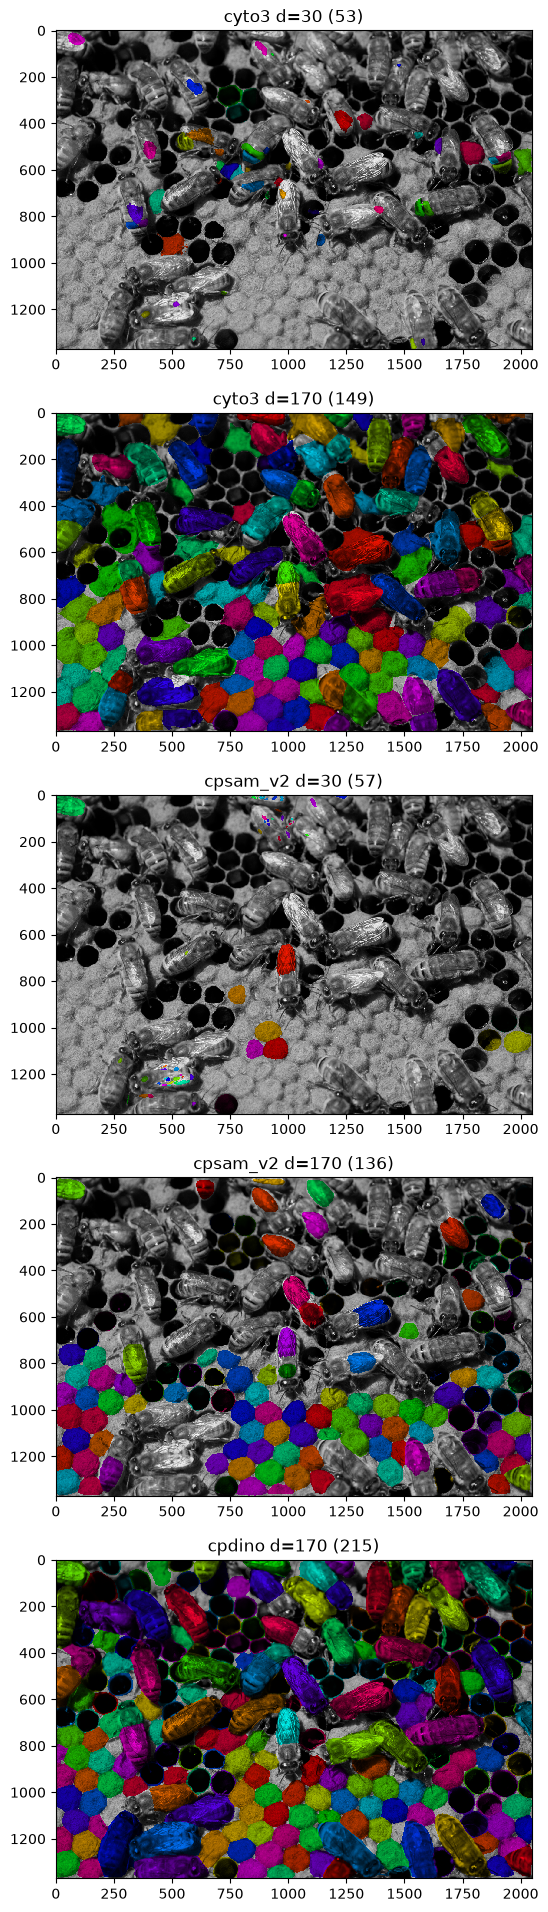

In [13]:
results = [cyto3_d30, cyto3_d170, cpsam_d30, cpsam_d170, cpdino_d170]
titles = [
    f'cyto3 d=30 ({cyto3_d30.max()})',
    f'cyto3 d=170 ({cyto3_d170.max()})',
    f'cpsam_v2 d=30 ({cpsam_d30.max()})',
    f'cpsam_v2 d=170 ({cpsam_d170.max()})',
    f'cpdino d=170 ({cpdino_d170.max()})',
]

# Cellpose's own way of showing this: image in grey, one colour per object.
overlays = [mask_overlay(img, r) for r in results]

fig = imshow_multi2d(overlays, titles, 5, 1, width=12, height=24)

## What to take from this

- None of these is good enough to count bees.
- Diameter moves Cellpose 3 a long way and Cellpose 4 hardly at all.
- Next: train on labelled patches and run the same comparison.